In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Math
import numpy as np

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Math

def plot_qdrift_results(df: pd.DataFrame, loglog: bool = True, y: str = "estimation_error") -> None:
    # -------------------------------------------------------------------------
    # Load and preprocess
    # -------------------------------------------------------------------------
    n_circuits = sorted(df["n_circuits"].unique())
    n_shots = sorted(df["n_shots"].unique())

    nrows, ncols = len(n_circuits), len(n_shots)
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=(4*ncols, 3.5*nrows), sharex=True, sharey=True
    )

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes[np.newaxis, :]
    elif ncols == 1:
        axes = axes[:, np.newaxis]

    # -------------------------------------------------------------------------
    # Main plotting loop
    # -------------------------------------------------------------------------
    for i, circ in enumerate(n_circuits):
        for j, shots in enumerate(n_shots):
            ax = axes[i, j]
            subset = df[(df["n_circuits"] == circ) & (df["n_shots"] == shots)]

            if subset.empty:
                ax.set_visible(False)
                continue

            sns.scatterplot(
                data=subset, x="time", y=y,
                ax=ax, s=40, color="C0", alpha=0.7
            )

            if loglog:
                ax.set_xscale("log")
                ax.set_yscale("log")

            # regression fit
            if len(subset) > 1:
                x_log = np.log10(subset["time"])
                y_log = np.log10(subset[y])
                coeffs = np.polyfit(x_log, y_log, 1)
                poly_eqn = np.poly1d(coeffs)
                r2 = np.corrcoef(x_log, y_log)[0, 1] ** 2

                x_vals = np.logspace(np.log10(subset["time"].min()), 
                                     np.log10(subset["time"].max()), 100)
                y_vals = 10 ** poly_eqn(np.log10(x_vals))
                ax.plot(x_vals, y_vals, color="gray", linestyle="--")

                display(Math(
                    f"\\text{{Fit for }} n_{{circuits}}={circ},\\; n_{{shots}}={shots}:"
                    f"\\; y={coeffs[0]:.2f}x + {coeffs[1]:.2f},\\; R^2={r2:.2f}"
                ))

            # titles & labels
            total_queries = circ * shots * 2 ** subset["num_ancilla"].iloc[0]
            # write in scientific notation if large
            if total_queries >= 1e4:
                total_queries = f"{total_queries:.4e}"
            ax.set_title(f"n_circuits={circ}, n_shots={shots} \nTotal queries={total_queries}", fontsize=10)
            if i == nrows - 1:
                ax.set_xlabel("Evolution time")
            if j == 0:
                ax.set_ylabel(y)

            ax.grid(True, which="both", ls="--", alpha=0.6)

            # show standard deviation if multiple points (df["est_energy_std"])
            if len(subset) > 1:
                ax.fill_between(
                    subset["time"], 
                    subset[y] - subset["est_energy_std"],
                    subset[y] + subset["est_energy_std"],
                    color="C0", alpha=0.2
                )
            lowest_error_idx = subset[y].idxmin()
            lowest_error_point = subset.loc[lowest_error_idx]
            # show in legend lowest error, to see if it aligns with theory
            print(f"Lowest {y} for n_circuits={circ}, n_shots={shots}: {lowest_error_point[y]} at time {lowest_error_point['time']}")
    plt.suptitle(f"QDrift {y} vs Evolution Time", fontsize=16)
    plt.legend()


    plt.tight_layout()
    plt.show()


# fit a degree 2 polynomial to the normal data (not log-log)
def fit_polynomial_and_plot(df: pd.DataFrame, degree: int = 2, y: str = "est_energy_med") -> None:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x="time", y=y, hue="n_circuits", palette="deep")

    # Fit polynomial
    coeffs = np.polyfit(df["time"], df[y], degree)
    poly_eqn = np.poly1d(coeffs)
    # Display polynomial equation
    equation_str = " + ".join([f"{coeff}x^{i}" for i, coeff in enumerate(reversed(coeffs))])
    display(Math(f"\\text{{Fitted polynomial (degree {degree}): }} y = {equation_str}"))

    # Generate x values for plotting the polynomial fit
    x_vals = np.linspace(df["time"].min(), df["time"].max(), 100)
    y_vals = poly_eqn(x_vals)

    plt.plot(x_vals, y_vals, color="red", linestyle="--", label=f"Degree {degree} fit")
    plt.xlabel("Evolution time")
    plt.ylabel(y)
    plt.title(f"Polynomial Fit to {y} vs Evolution Time")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.6)
    lowest_error_idx = df[y].idxmin()
    lowest_error_point = df.loc[lowest_error_idx]
    plt.scatter(lowest_error_point["time"], lowest_error_point[y], color="green", s=100, label="Lowest Error Point")
    plt.legend()
    plt.show()



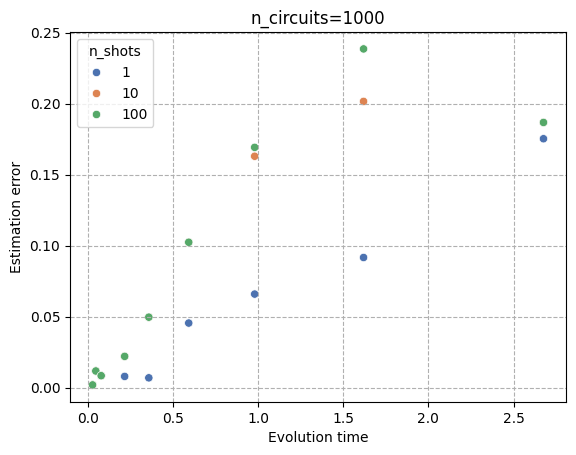

In [14]:
df = pd.read_csv(r"C:\Users\rodcs\Desktop\my-repos\qDriftExtraPolation\qdrift_qpe_cleaned.csv")
# df = df[df["time"] > df["time"].min()]  # filter for specific ancilla count if needed

for groupname, groupdf in df.groupby(["n_circuits"]):
    plt.figure()
    sns.scatterplot(data=groupdf,
                    x="time",
                    y="estimation_error",
                    hue="n_shots",
                    palette="deep")
    plt.title(f"n_circuits={groupname[0]}")
    plt.xlabel("Evolution time")
    plt.ylabel("Estimation error")
    plt.grid(True, which="both", ls="--")


<IPython.core.display.Math object>

Lowest error_according_to_mean for n_circuits=1000, n_shots=1: 0.007491530263802115 at time 0.5934536899745164


<IPython.core.display.Math object>

Lowest error_according_to_mean for n_circuits=1000, n_shots=10: 0.002160016490418859 at time 0.0292024680254248


<IPython.core.display.Math object>

Lowest error_according_to_mean for n_circuits=1000, n_shots=100: 0.0019498998952667268 at time 0.0292024680254248


C:\Users\rodcs\AppData\Local\Temp\ipykernel_15224\1427714968.py:92: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


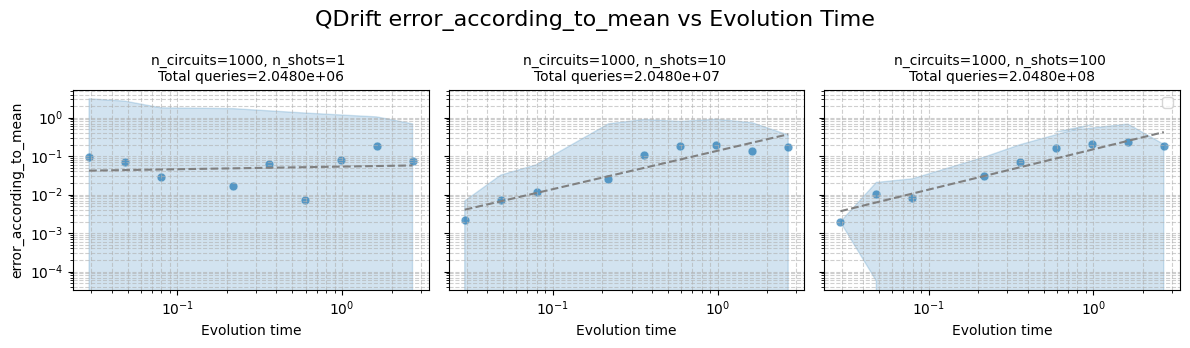

<IPython.core.display.Math object>

Lowest estimation_error for n_circuits=1000, n_shots=1: 0.0019498998952555 at time 0.0292024680254248


<IPython.core.display.Math object>

Lowest estimation_error for n_circuits=1000, n_shots=10: 0.0019498998952555 at time 0.0292024680254248


<IPython.core.display.Math object>

Lowest estimation_error for n_circuits=1000, n_shots=100: 0.0019498998952555 at time 0.0292024680254248


C:\Users\rodcs\AppData\Local\Temp\ipykernel_15224\1427714968.py:92: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


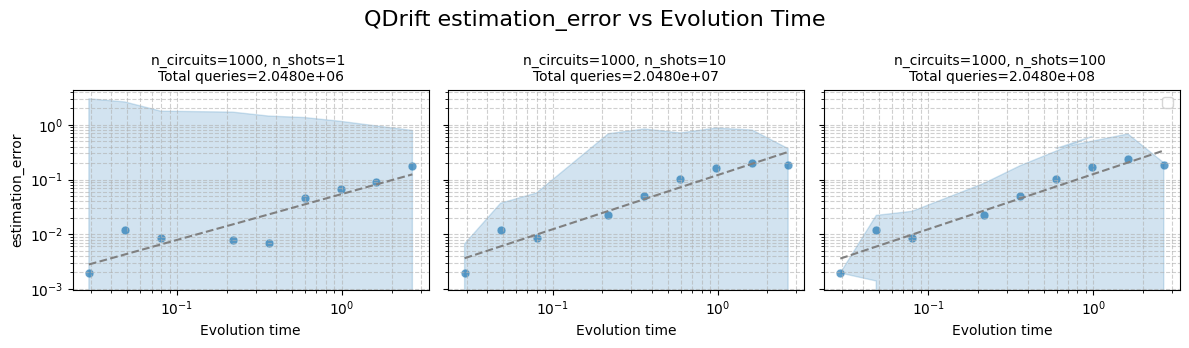

In [19]:

df["error_according_to_mean"] = abs(df["est_energy_mean"] - df["exact_eig"])
plot_qdrift_results(df, y="error_according_to_mean")
plot_qdrift_results(df, loglog=True, y="estimation_error")


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

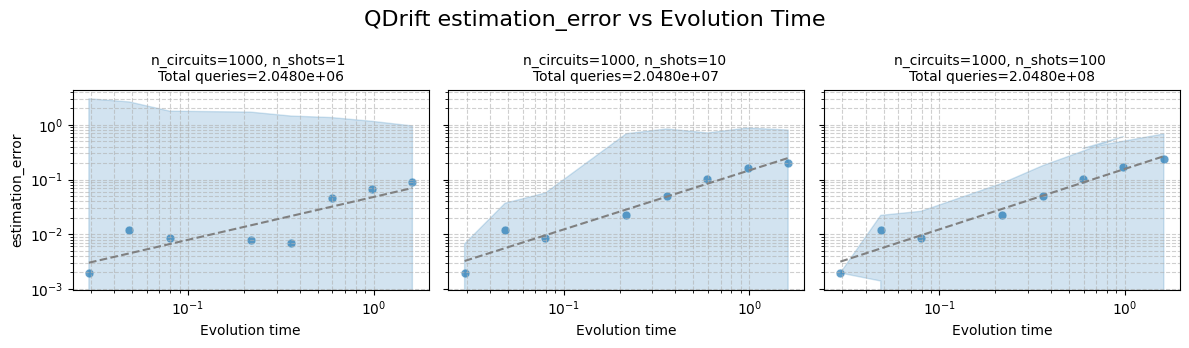

In [10]:
df_without_last_time = df[df["time"] < df["time"].max()]
plot_qdrift_results(df_without_last_time)

In [ ]:
plot_qdrift_results(df, loglog=True, y="est_energy_med")

<IPython.core.display.Math object>

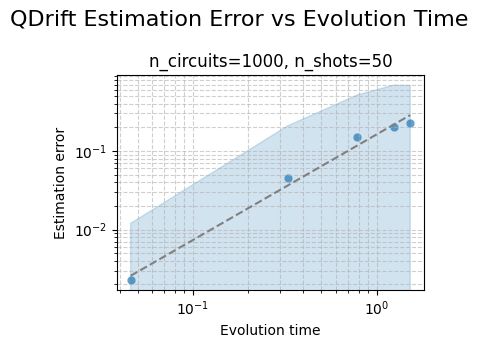

In [ ]:
df2 = pd.read_csv(r"C:\Users\rodcs\Desktop\my-repos\qDriftExtraPolation\qdrift_qpe_fc_parameter_sweep_2025-10-02.csv")
df2=df2[df2["ham"] == "1 qubit test"]
plot_qdrift_results(df2)

<IPython.core.display.Math object>

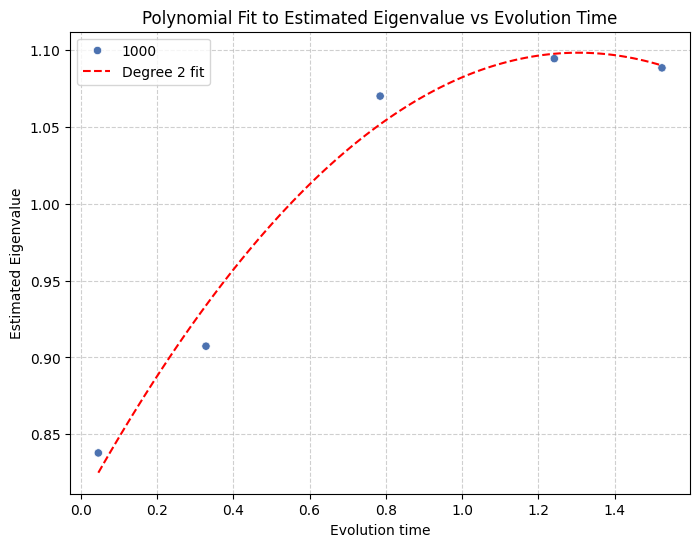

In [ ]:
# plot estimated eigenvalue vs t and fit a polynomial of degree 2
def plot_estimated_eigenvalue_and_fit(df: pd.DataFrame, degree: int = 2) -> None:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x="time", y="est_energy_mean", hue="n_circuits", palette="deep")

    # Fit polynomial
    coeffs = np.polyfit(df["time"], df["est_energy_mean"], degree)
    poly_eqn = np.poly1d(coeffs)
    # Display polynomial equation
    equation_str = " + ".join([f"{coeff}x^{i}" for i, coeff in enumerate(reversed(coeffs))])
    display(Math(f"\\text{{Fitted polynomial (degree {degree}): }} y = {equation_str}"))

    # Generate x values for plotting the polynomial fit
    x_vals = np.linspace(df["time"].min(), df["time"].max(), 100)
    y_vals = poly_eqn(x_vals)

    plt.plot(x_vals, y_vals, color="red", linestyle="--", label=f"Degree {degree} fit")
    plt.xlabel("Evolution time")
    plt.ylabel("Estimated Eigenvalue")
    plt.title("Polynomial Fit to Estimated Eigenvalue vs Evolution Time")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.6)
    plt.show()
plot_estimated_eigenvalue_and_fit(df2, degree=2)

<IPython.core.display.Math object>

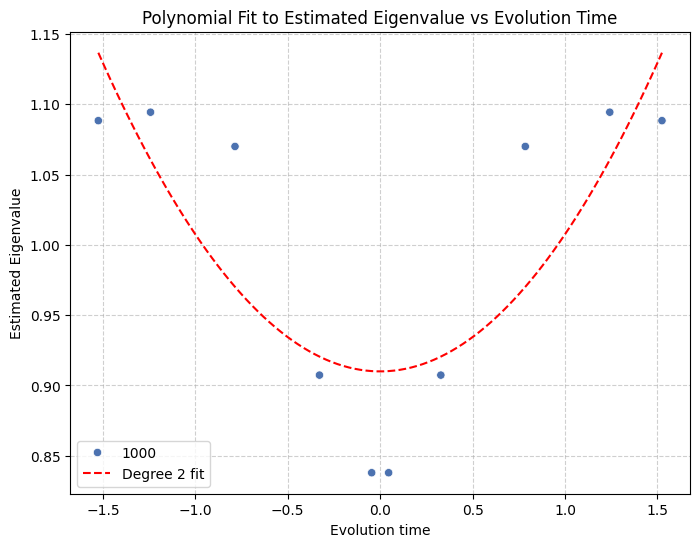

In [ ]:
# reflect eigenvalue estimates around t = 0 to double the data points
df_reflected = df2.copy()
df_reflected["time"] = -df_reflected["time"]
df_reflected = pd.concat([df2, df_reflected], ignore_index=True)
plot_estimated_eigenvalue_and_fit(df_reflected, degree=2)

In [ ]:
#  check if the extrapolated value at t=0 matches the exact eigenvalue
def extrapolate_to_zero(df: pd.DataFrame, degree: int = 2) -> float:
    coeffs = np.polyfit(df["time"], df["estimation_error"], degree)
    poly_eqn = np.poly1d(coeffs)
    extrapolated_value = poly_eqn(0)
    display(Math(f"\\text{{Extrapolated value at time=0: }} y(0) = {extrapolated_value:.4f}"))
    display(Math(f"\\text{{Exact eigenvalue: }} {df['exact_eig'].iloc[0]:.4f}"))
    return extrapolated_value
extrapolate_to_zero(df2)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

np.float64(-0.015111653028807513)

In [ ]:
# extrapolate to time = 0 using the polynomial fit
def extrapolate_to_zero(df: pd.DataFrame, degree: int = 2) -> float:
    coeffs = np.polyfit(df["time"], df["estimation_error"], degree)
    poly_eqn = np.poly1d(coeffs)
    extrapolated_value = poly_eqn(0)
    display(Math(f"\\text{{Extrapolated value at time=0: }} y(0) = {extrapolated_value:.4f}"))
    return extrapolated_value
extrapolate_to_zero(df2)

<IPython.core.display.Math object>

np.float64(-0.015111653028807513)